# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Collage ROI Dataset](https://www.kaggle.com/datasets/sergionefedov/college-major-roi?select=college_major_roi.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('college_major_roi.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,grad_id,major,major_category,institution_tier,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
0,G000000,biology,STEM,mid_tier,52,2.58,0,0,south,144400,0,411700,101000,512700,-43400,-30.0,0,0
1,G000001,marketing,business,mid_tier,61,2.58,0,1,northeast,57400,0,356900,330600,687500,273200,476.1,1,0
2,G000002,electrical_engineering,STEM,top_public,78,3.14,1,1,northeast,65100,39600,339600,655100,994700,590000,906.4,1,1
3,G000003,marketing,business,top_public,77,3.04,0,1,midwest,105800,81300,399600,197500,597100,91700,86.8,1,0
4,G000004,marketing,business,ivy_elite,100,3.81,0,0,south,219200,93500,335700,222900,558600,3800,1.7,1,0


## last Five row

In [4]:
df.tail()

,grad_id,major,major_category,institution_tier,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
29995,G029995,electrical_engineering,STEM,top_public,71,3.47,1,1,south,71900,0,338500,521600,860100,449700,625.4,1,1
29996,G029996,humanities,humanities,regional,46,3.62,0,1,south,61300,41300,378100,55400,433500,-5900,-9.6,0,0
29997,G029997,economics,business,for_profit,26,3.34,0,1,west,154000,0,432900,406500,839400,252500,163.9,1,0
29998,G029998,social_work,social_science,mid_tier,58,2.95,0,0,northeast,124100,50300,423300,53500,476800,-70500,-56.9,0,0
29999,G029999,chemical_engineering,STEM,regional,38,2.35,1,1,midwest,53900,51800,381800,602100,983800,548200,1016.9,1,1


## Shape of our dataset

In [5]:
df.shape

(30000, 18)

## List out all columns

In [6]:
df.columns

Index(['grad_id', 'major', 'major_category', 'institution_tier',
       'institution_selectivity_pctile', 'gpa', 'had_internship',
       'completed_on_time', 'region', 'net_cost_usd', 'debt_usd',
       'hs_baseline_10yr_usd', 'added_earnings_10yr_usd', 'earnings_10yr_usd',
       'net_roi_usd', 'roi_pct', 'positive_roi', 'high_roi'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

grad_id                            object
major                              object
major_category                     object
institution_tier                   object
institution_selectivity_pctile      int64
gpa                               float64
had_internship                      int64
completed_on_time                   int64
region                             object
net_cost_usd                        int64
debt_usd                            int64
hs_baseline_10yr_usd                int64
added_earnings_10yr_usd             int64
earnings_10yr_usd                   int64
net_roi_usd                         int64
roi_pct                           float64
positive_roi                        int64
high_roi                            int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   grad_id                         30000 non-null  object 
 1   major                           30000 non-null  object 
 2   major_category                  30000 non-null  object 
 3   institution_tier                30000 non-null  object 
 4   institution_selectivity_pctile  30000 non-null  int64  
 5   gpa                             30000 non-null  float64
 6   had_internship                  30000 non-null  int64  
 7   completed_on_time               30000 non-null  int64  
 8   region                          30000 non-null  object 
 9   net_cost_usd                    30000 non-null  int64  
 10  debt_usd                        30000 non-null  int64  
 11  hs_baseline_10yr_usd            30000 non-null  int64  
 12  added_earnings_10yr_usd         

## Check Null Value

In [9]:
df.isnull().sum()

grad_id                           0
major                             0
major_category                    0
institution_tier                  0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
hs_baseline_10yr_usd              0
added_earnings_10yr_usd           0
earnings_10yr_usd                 0
net_roi_usd                       0
roi_pct                           0
positive_roi                      0
high_roi                          0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,institution_selectivity_pctile,gpa,had_internship,completed_on_time,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,3.000000e+04,3.000000e+04,30000.000000,30000.000000,30000.00000
mean,55.086067,3.093337,0.436067,0.682367,88621.496667,38498.063333,359893.416667,3.554752e+05,7.153680e+05,2.668537e+05,346.153987,0.835167,0.25000
std,18.593708,0.439060,0.495904,0.465564,33576.903160,37801.748200,39923.943255,2.948109e+05,2.977847e+05,2.949958e+05,398.666879,0.371036,0.43302
min,16.000000,1.500000,0.000000,0.000000,28500.000000,0.000000,250000.000000,1.000000e+04,2.723000e+05,-3.052000e+05,-92.100000,0.000000,0.00000
25%,42.000000,2.790000,0.000000,0.000000,65500.000000,0.000000,333100.000000,1.179000e+05,4.835000e+05,3.280000e+04,39.700000,1.000000,0.00000
50%,55.000000,3.100000,0.000000,1.000000,81000.000000,38700.000000,359700.000000,2.836500e+05,6.458000e+05,1.981000e+05,230.900000,1.000000,0.00000
75%,68.000000,3.400000,1.000000,1.000000,103600.000000,62300.000000,387300.000000,5.093000e+05,8.717000e+05,4.235250e+05,537.400000,1.000000,0.25000
max,102.000000,4.000000,1.000000,1.000000,352900.000000,331700.000000,480000.000000,2.894900e+06,3.245500e+06,2.755100e+06,3618.900000,1.000000,1.00000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

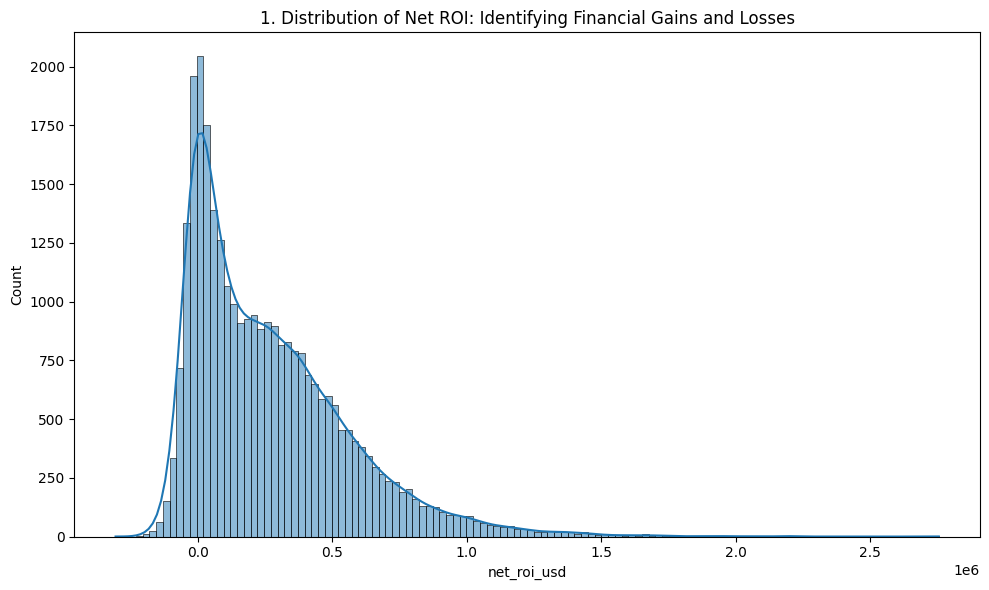

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='net_roi_usd', kde=True)
plt.title(f'{plot_no}. Distribution of Net ROI: Identifying Financial Gains and Losses')
show_fig()
plot_no += 1

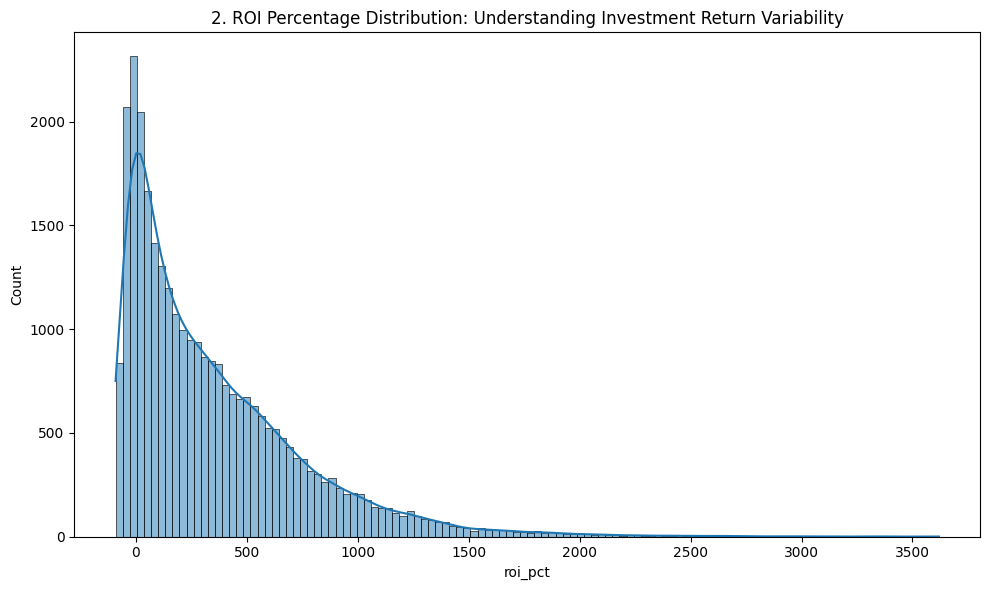

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='roi_pct', kde=True)
plt.title(f'{plot_no}. ROI Percentage Distribution: Understanding Investment Return Variability')
show_fig()
plot_no += 1

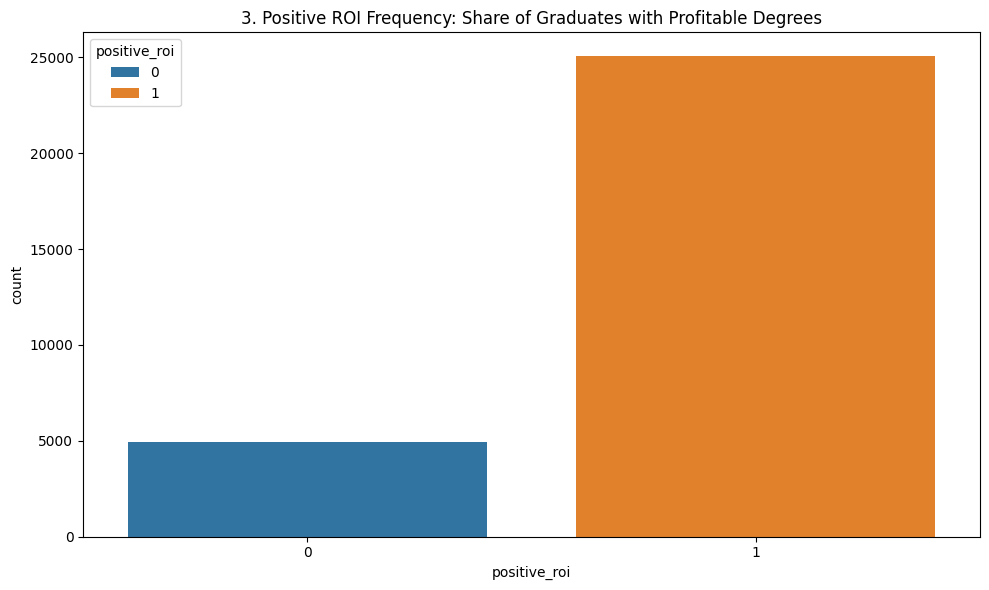

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='positive_roi', hue='positive_roi')
plt.title(f'{plot_no}. Positive ROI Frequency: Share of Graduates with Profitable Degrees')
show_fig()
plot_no += 1

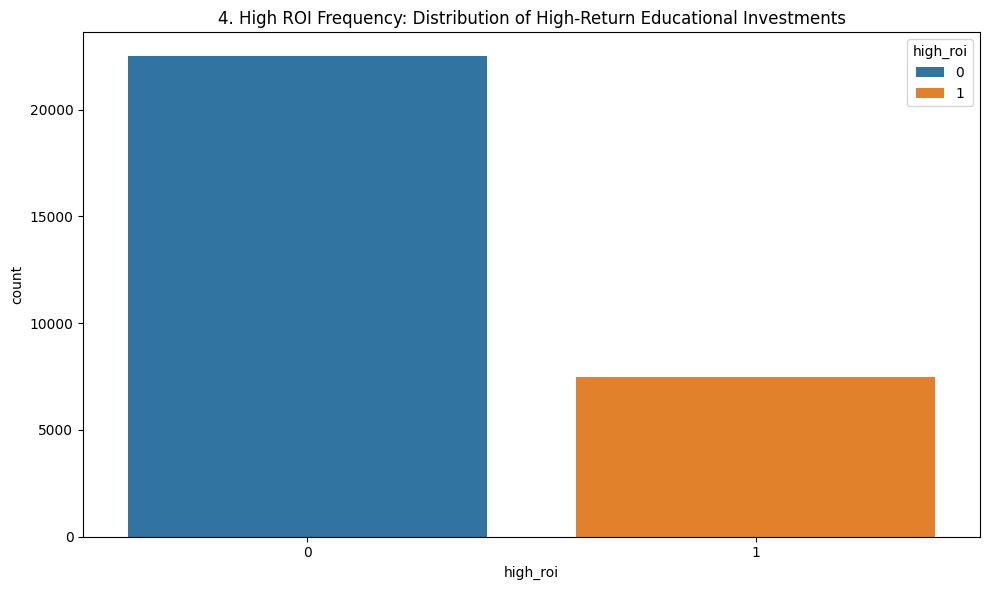

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='high_roi', hue='high_roi')
plt.title(f'{plot_no}. High ROI Frequency: Distribution of High-Return Educational Investments')
show_fig()
plot_no += 1

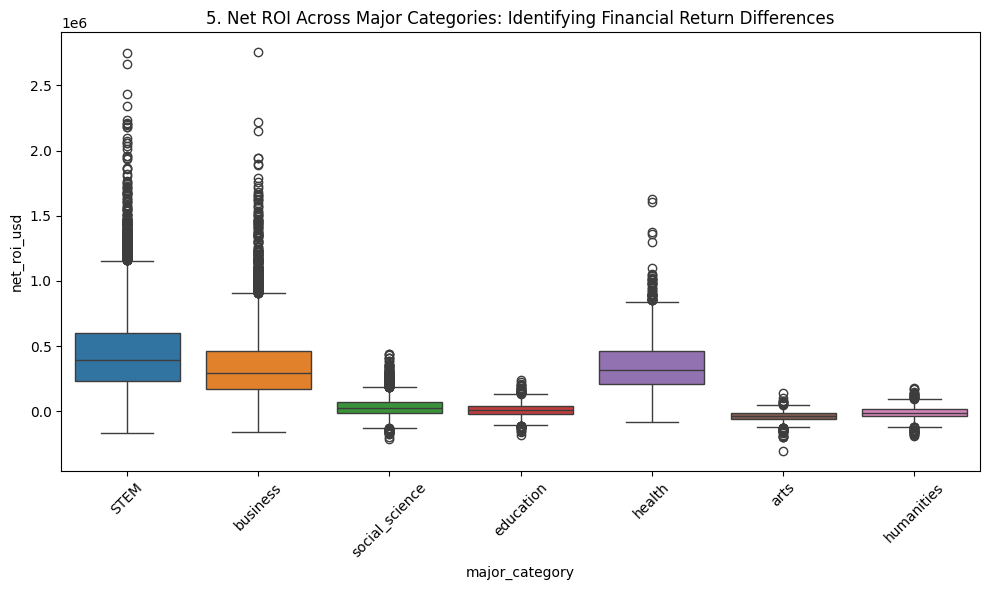

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='major_category', y='net_roi_usd', hue='major_category', legend=False)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Net ROI Across Major Categories: Identifying Financial Return Differences')
show_fig()
plot_no += 1

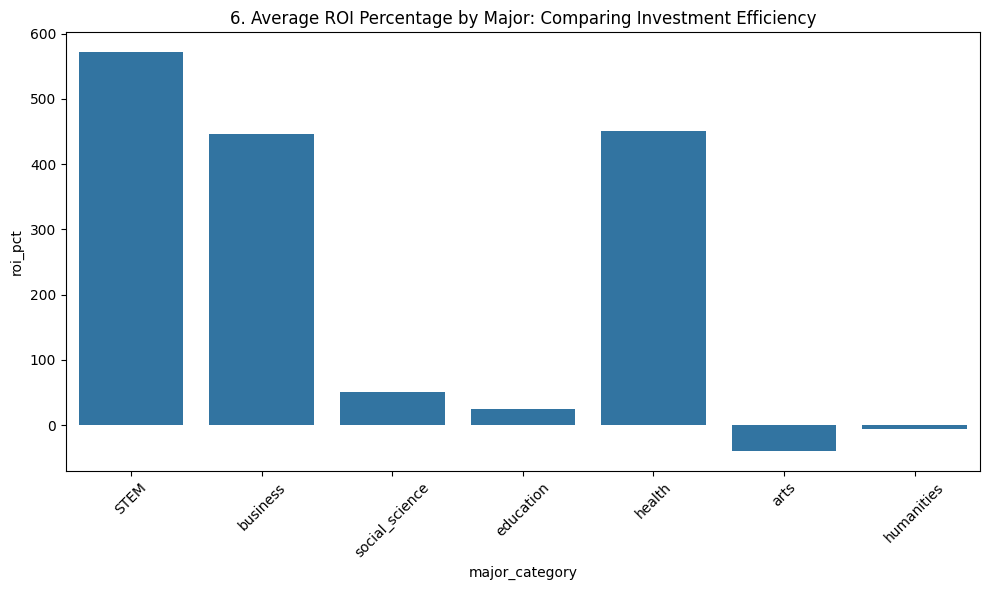

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='major_category', y='roi_pct', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average ROI Percentage by Major: Comparing Investment Efficiency')
show_fig()
plot_no += 1

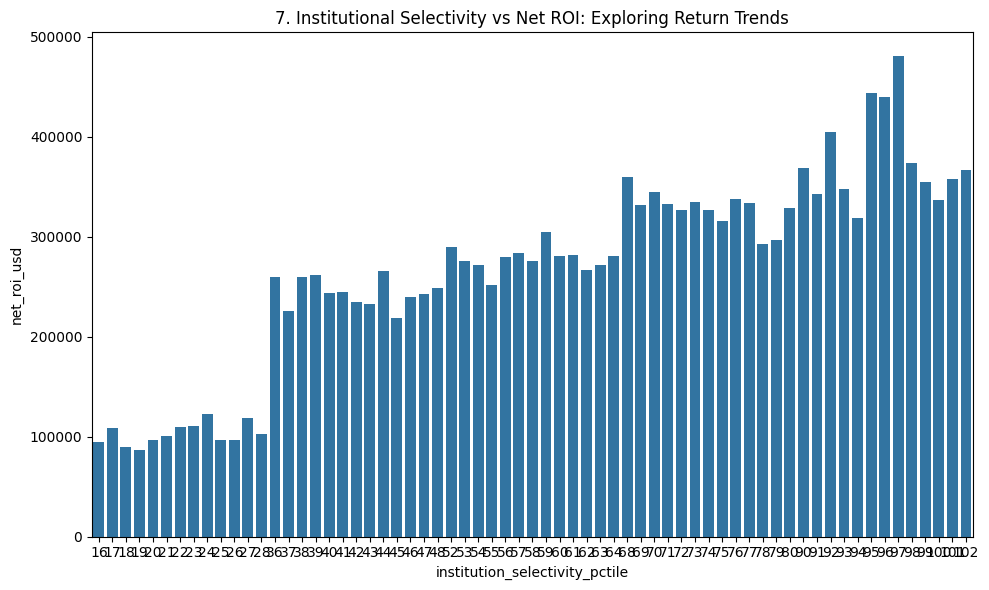

In [19]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='institution_selectivity_pctile', y='net_roi_usd', errorbar=None)
plt.title(f'{plot_no}. Institutional Selectivity vs Net ROI: Exploring Return Trends')
show_fig()
plot_no += 1

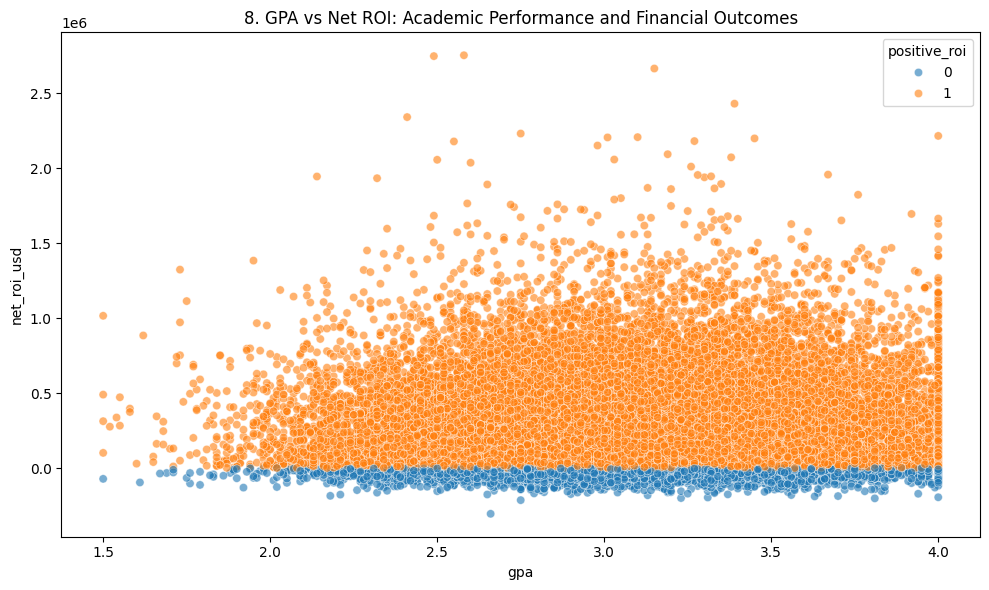

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gpa', y='net_roi_usd', hue='positive_roi', alpha=0.6)
plt.title(f'{plot_no}. GPA vs Net ROI: Academic Performance and Financial Outcomes')
show_fig()
plot_no += 1

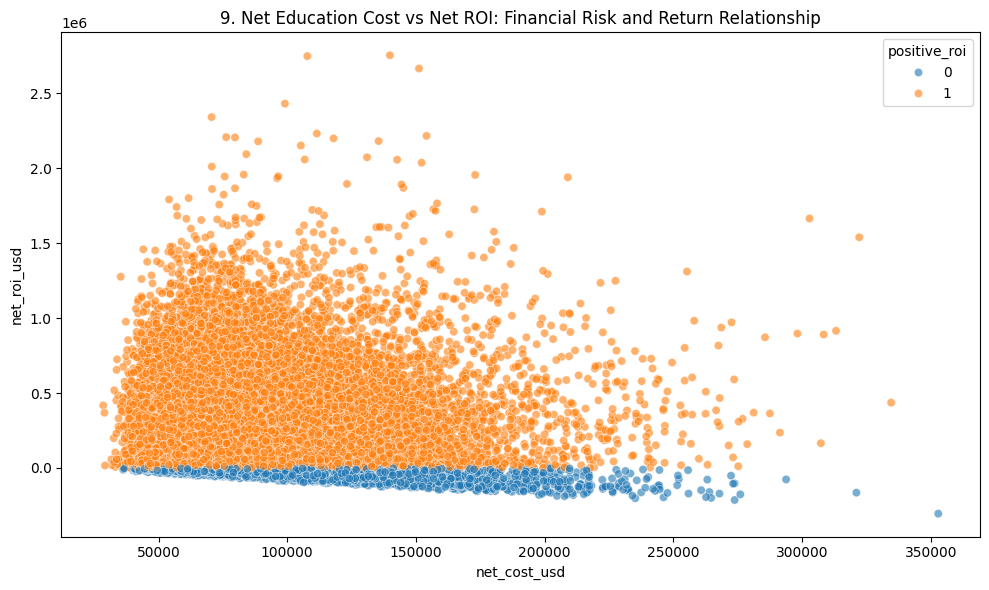

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='net_cost_usd', y='net_roi_usd', hue='positive_roi', alpha=0.6)
plt.title(f'{plot_no}. Net Education Cost vs Net ROI: Financial Risk and Return Relationship')
show_fig()
plot_no += 1

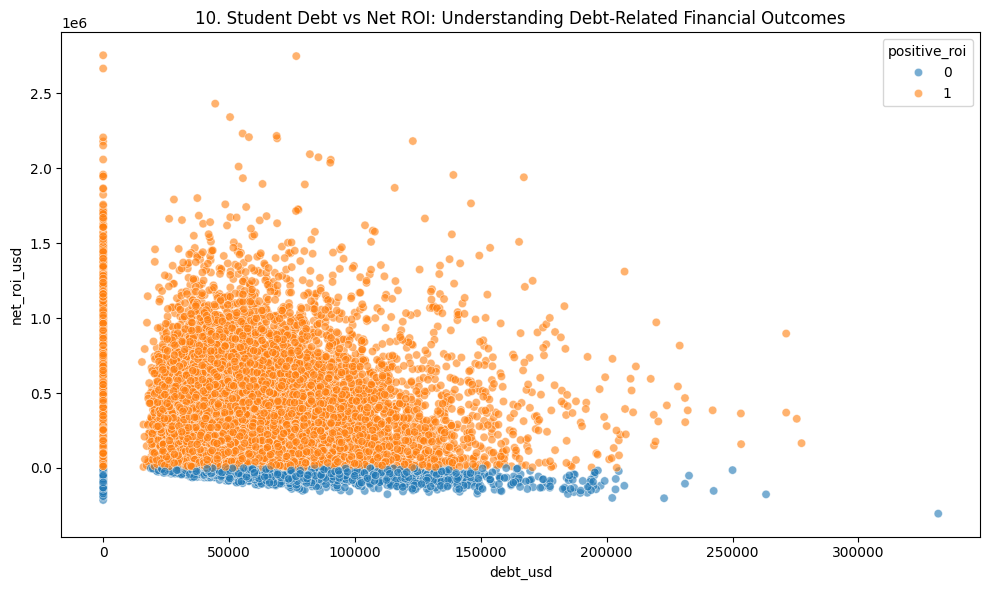

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='debt_usd', y='net_roi_usd', hue='positive_roi', alpha=0.6)
plt.title(f'{plot_no}. Student Debt vs Net ROI: Understanding Debt-Related Financial Outcomes')
show_fig()
plot_no += 1

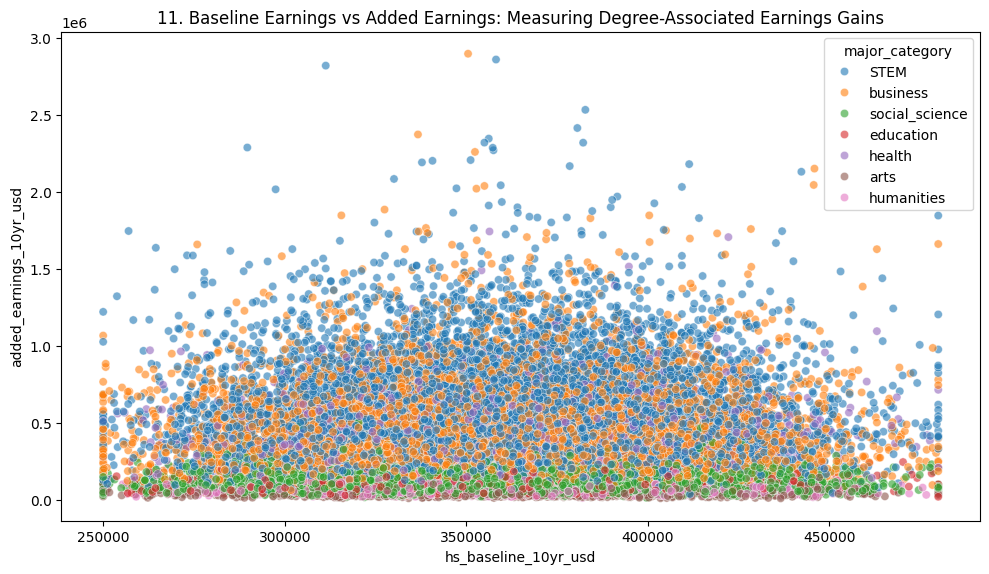

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='hs_baseline_10yr_usd', y='added_earnings_10yr_usd', hue='major_category', alpha=0.6)
plt.title(f'{plot_no}. Baseline Earnings vs Added Earnings: Measuring Degree-Associated Earnings Gains')
show_fig()
plot_no += 1

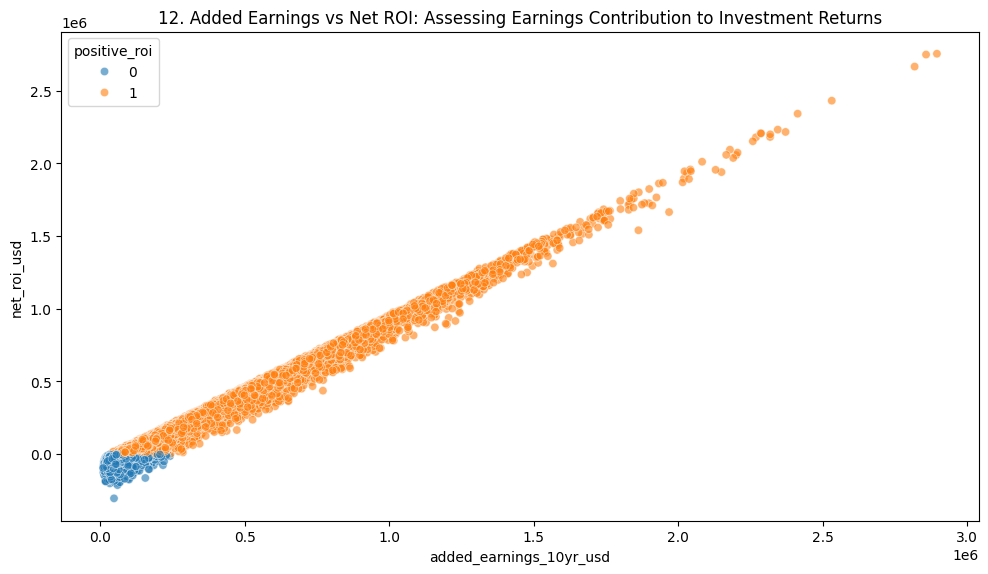

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='added_earnings_10yr_usd', y='net_roi_usd', hue='positive_roi', alpha=0.6)
plt.title(f'{plot_no}. Added Earnings vs Net ROI: Assessing Earnings Contribution to Investment Returns')
show_fig()
plot_no += 1

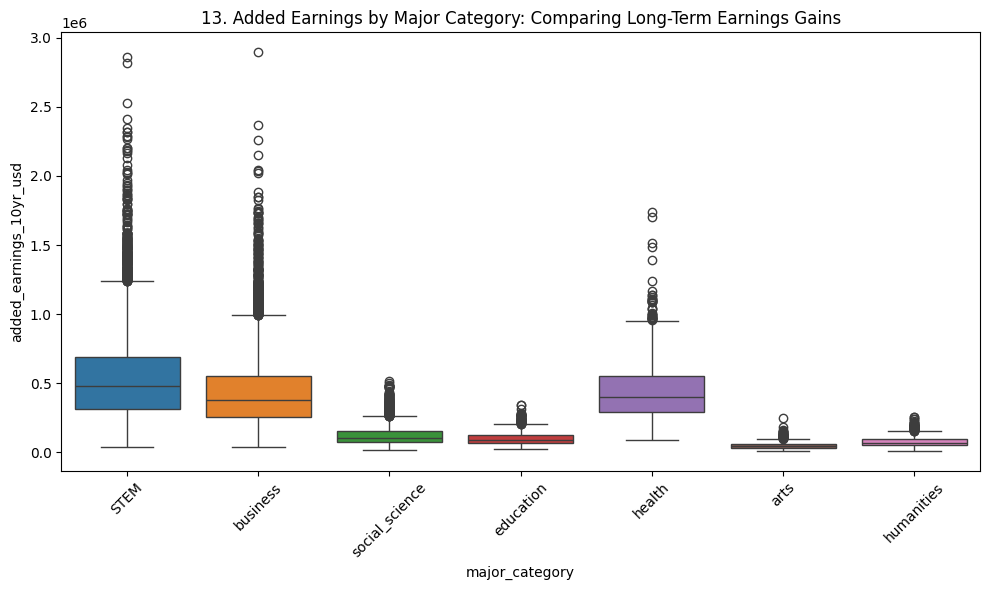

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='major_category', y='added_earnings_10yr_usd', hue='major_category', legend=False)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Added Earnings by Major Category: Comparing Long-Term Earnings Gains')
show_fig()
plot_no += 1

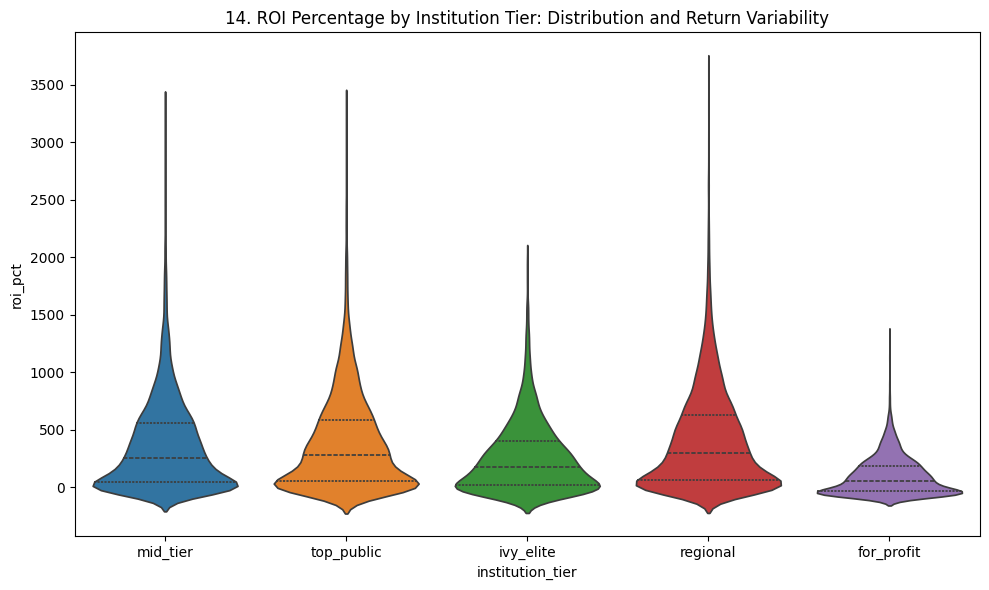

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='institution_tier', y='roi_pct', hue='institution_tier', legend=False, inner='quartile')
plt.title(f'{plot_no}. ROI Percentage by Institution Tier: Distribution and Return Variability')
show_fig()
plot_no += 1

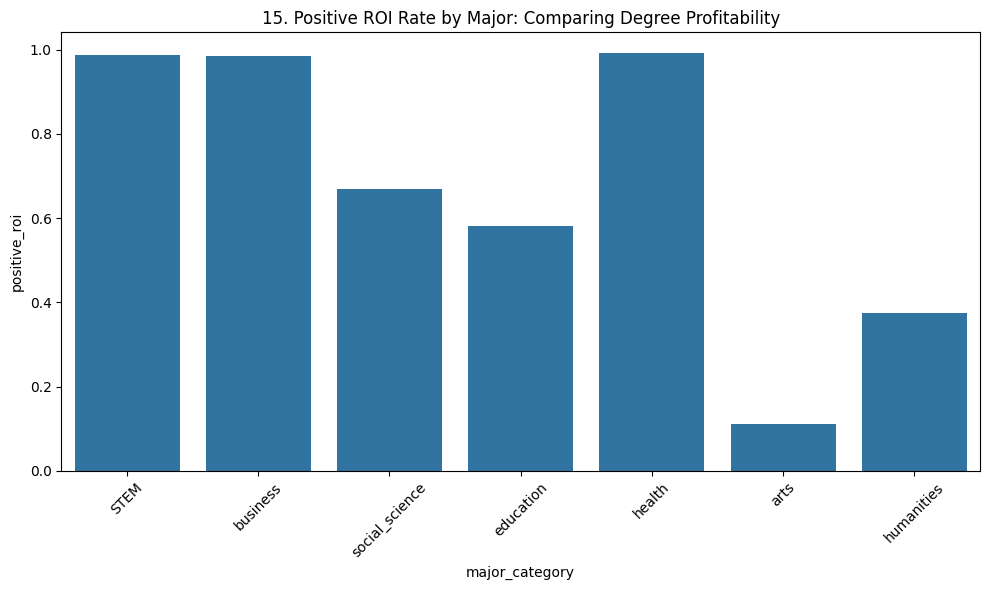

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='major_category', y='positive_roi', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Positive ROI Rate by Major: Comparing Degree Profitability')
show_fig()
plot_no += 1

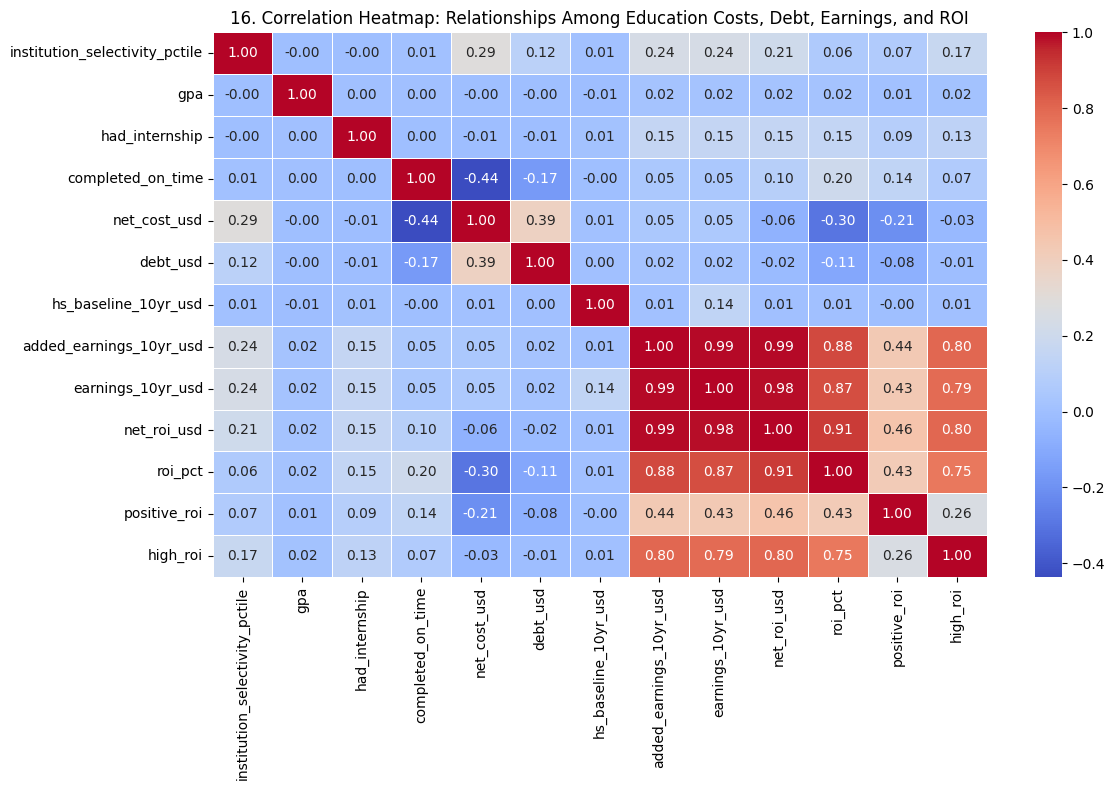

In [28]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').drop(columns=['grad_id'], errors='ignore').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap: Relationships Among Education Costs, Debt, Earnings, and ROI')
show_fig()
plot_no += 1

# Model Training

## Select features and target while avoiding target leakage

In [29]:
X = df.drop(columns=[
    'grad_id', 'positive_roi', 'high_roi',
    'net_roi_usd', 'roi_pct',
    'added_earnings_10yr_usd', 'earnings_10yr_usd'
], errors='ignore')

y = df['high_roi']

## Identify numerical and categorical columns

In [30]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

## Preprocess missing values, scale numerical features, and encode categories

In [31]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

## Split data into training and testing sets

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Build a gradient boosting classification pipeline

In [33]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=20,
        l2_regularization=2.0,
        random_state=42
    ))
])

## Train the model

In [34]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions and evaluate accuracy

In [35]:
y_pred = model.predict(X_test)

print("Model: HistGradientBoostingClassifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Model: HistGradientBoostingClassifier
Accuracy: 0.8268

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      4500
           1       0.66      0.65      0.65      1500

    accuracy                           0.83      6000
   macro avg       0.77      0.77      0.77      6000
weighted avg       0.83      0.83      0.83      6000



## Plot the confusion matrix

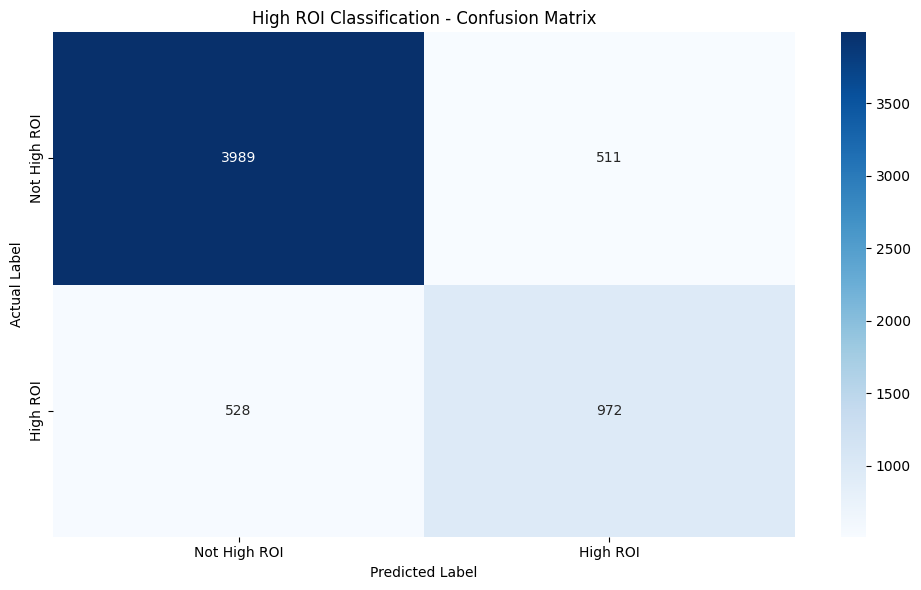

In [36]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not High ROI', 'High ROI'],
    yticklabels=['Not High ROI', 'High ROI']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('High ROI Classification - Confusion Matrix')
plt.tight_layout()
plt.show()